In [1]:
!pip install -q nltk Sastrawi wordcloud tqdm pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 11.3 MB/s eta 0:00:00


In [2]:
# import lib
import os
import re
import json
import string
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from tqdm import tqdm
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

warnings.filterwarnings('ignore')
tqdm.pandas()

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

print("Import selesai.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Import selesai.


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
# load datasate
df = pd.read_csv('/content/review_new_sakpole.csv')

In [4]:
# Menampilkan lima data teratas.
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,a9116c12-e4fd-44a7-b47d-2aa5d7124a85,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi bermasalah.Error saat mau masuk menu ...,1,10,3.1.4,2026-04-17 12:59:26,NaN,NaN,3.1.4
1,af1edd25-923f-45bb-b493-65c2cedb6530,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi membantu cek brp pembayaran pajaknya....,5,0,3.1.4,2026-05-20 11:17:50,NaN,NaN,3.1.4
2,4e0142ea-2466-4cc8-bed5-041e80a2d772,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa blm masuk juga padahal suda bayar Lo in...,1,2,3.1.4,2026-05-15 20:49:39,NaN,NaN,3.1.4
3,519db25e-4342-438f-96c3-9b1f2e80e0ed,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"jelek banget sii pelayanannya, beda banget kal...",1,5,3.1.4,2026-05-02 10:13:38,NaN,NaN,3.1.4
4,04514bcd-63df-4c76-adb3-95194a09b767,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Seperti biasa, aplikasi instansi pemerintah BU...",1,0,3.1.4,2026-05-23 10:39:02,NaN,NaN,3.1.4


In [5]:
print(df.isnull().sum())
print(f"Jumlah duplikat: {df.duplicated().sum()}")

reviewId                    0
userName                    0
userImage                   0
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion     3435
at                          0
replyContent            17339
repliedAt               17339
appVersion               3435
dtype: int64
Jumlah duplikat: 0


In [6]:
print(df.describe(include='all'))

                                    reviewId         userName  \
count                                  17588            17588   
unique                                 17588                1   
top     2ef1ee10-3561-4140-b17a-99aed66a53da  Pengguna Google   
freq                                       1            17588   
mean                                     NaN              NaN   
std                                      NaN              NaN   
min                                      NaN              NaN   
25%                                      NaN              NaN   
50%                                      NaN              NaN   
75%                                      NaN              NaN   
max                                      NaN              NaN   

                                                userImage          content  \
count                                               17588            17588   
unique                                                  1      

In [9]:
SLANG_URL = "https://raw.githubusercontent.com/adeariniputri/text-preprocesing/master/slang.csv"

slang_dict = {}

try:
    slang_df = pd.read_csv(SLANG_URL, header=None, names=['slang', 'formal'])
    slang_dict = dict(zip(slang_df['slang'].str.lower(), slang_df['formal'].str.lower()))
    print(f"Kamus slang berhasil dimuat dari GitHub. Total entri: {len(slang_dict)}")
except Exception as e:
    print(f"Gagal memuat dari GitHub: {e}")
    local_path = 'data/slang_dictionary.csv'
    if os.path.exists(local_path):
        slang_df = pd.read_csv(local_path, header=None, names=['slang', 'formal'])
        slang_dict = dict(zip(slang_df['slang'].str.lower(), slang_df['formal'].str.lower()))
        print(f"Kamus slang dimuat dari lokal: {local_path}. Total entri: {len(slang_dict)}")
    else:
        print("Kamus slang tidak tersedia. Normalisasi slang dilewati.")
        print("Unduh manual dari: https://github.com/adeariniputri/text-preprocesing/blob/master/slang.csv")
        print("Simpan ke: data/slang_dictionary.csv")

Kamus slang berhasil dimuat dari GitHub. Total entri: 1481


In [7]:
# Inisialisasi stemmer dan stopwords
factory = StemmerFactory()
stemmer = factory.create_stemmer()

id_stopwords = set(stopwords.words('indonesian'))
en_stopwords = set(stopwords.words('english'))
all_stopwords = id_stopwords.union(en_stopwords)

def remove_mentions(text):
    return re.sub(r'@\w+', ' ', text)

def remove_hashtags(text):
    return re.sub(r'#\w+', ' ', text)

def remove_rt(text):
    return re.sub(r'\bRT\b', ' ', text)

def remove_urls(text):
    return re.sub(r'http\S+|www\.\S+', ' ', text)

def remove_numbers(text):
    return re.sub(r'\d+', ' ', text)

def remove_punctuation(text):
    return text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))

def remove_newlines(text):
    return text.replace('\n', ' ').replace('\r', ' ')

def normalize_whitespace(text):
    return re.sub(r'\s+', ' ', text).strip()

def case_folding(text):
    return text.lower()

def normalize_slang(text, slang_dict):
    if not slang_dict:
        return text
    words = text.split()
    return ' '.join([slang_dict.get(w, w) for w in words])

def tokenize(text):
    return word_tokenize(text)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in all_stopwords and len(t) > 1]

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

def preprocess_text(text):
    if pd.isna(text) or str(text).strip() == '':
        return ''
    text = str(text)
    text = remove_mentions(text)
    text = remove_hashtags(text)
    text = remove_rt(text)
    text = remove_urls(text)
    text = remove_numbers(text)
    text = remove_punctuation(text)
    text = remove_newlines(text)
    text = normalize_whitespace(text)
    text = case_folding(text)
    text = normalize_slang(text, slang_dict)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = stem_tokens(tokens)
    return ' '.join(tokens)

print("Fungsi preprocessing siap.")

Fungsi preprocessing siap.


In [10]:
print("Memulai preprocessing... (mungkin memakan waktu beberapa menit)")
df['clean_text'] = df['content'].progress_apply(preprocess_text)

# Hapus baris dengan clean_text kosong
before = len(df)
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
after = len(df)
print(f"Baris dihapus karena clean_text kosong: {before - after}")
print(f"Total data setelah cleaning: {after}")
df[['content', 'clean_text']].head(5)

Memulai preprocessing... (mungkin memakan waktu beberapa menit)


100%|██████████| 17588/17588 [15:51<00:00, 18.47it/s]

Baris dihapus karena clean_text kosong: 400
Total data setelah cleaning: 17188


,content,clean_text
0,Aplikasi bermasalah.Error saat mau masuk menu ...,aplikasi masalah ganggu masuk menu bayar kali ...
1,aplikasi membantu cek brp pembayaran pajaknya....,aplikasi bantu cek brp bayar pajak saran bayar...
2,kenapa blm masuk juga padahal suda bayar Lo in...,blm masuk suda bayar tolong tindak lanjut baya...
3,"jelek banget sii pelayanannya, beda banget kal...",jelek sii layan beda pakai apk jaring langsung...
4,"Seperti biasa, aplikasi instansi pemerintah BU...",aplikasi instansi perintah busuk ngecek biaya ...


In [11]:
POS_URL = "https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv"
NEG_URL = "https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv"

def load_lexicon(url, col_word='word', col_weight='weight'):
    try:
        lex_df = pd.read_csv(url)
        print(f"Kolom lexicon: {lex_df.columns.tolist()}")
        # Deteksi kolom otomatis
        word_col = col_word if col_word in lex_df.columns else lex_df.columns[0]
        weight_col = col_weight if col_weight in lex_df.columns else (lex_df.columns[1] if len(lex_df.columns) > 1 else None)
        if weight_col:
            return dict(zip(lex_df[word_col].str.lower(), lex_df[weight_col]))
        else:
            return {w.lower(): 1 for w in lex_df[word_col]}
    except Exception as e:
        print(f"Gagal memuat lexicon dari {url}: {e}")
        return {}

print("Memuat lexicon positif...")
pos_lexicon = load_lexicon(POS_URL)
print(f"Total kata positif: {len(pos_lexicon)}")

print("\nMemuat lexicon negatif...")
neg_lexicon = load_lexicon(NEG_URL)
print(f"Total kata negatif: {len(neg_lexicon)}")

Memuat lexicon positif...
Kolom lexicon: ['hai', '3']
Total kata positif: 3606

Memuat lexicon negatif...
Kolom lexicon: ['putus tali gantung', '-2']
Total kata negatif: 6605


In [12]:
def calculate_sentiment_score(text):
    if not text or str(text).strip() == '':
        return 0
    tokens = str(text).split()
    score = 0
    for token in tokens:
        if token in pos_lexicon:
            score += pos_lexicon[token]
        elif token in neg_lexicon:
            score -= abs(neg_lexicon[token])
    return score

def score_to_label(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

print("Menghitung skor sentimen...")
df['sentiment_score'] = df['clean_text'].progress_apply(calculate_sentiment_score)
df['sentiment'] = df['sentiment_score'].apply(score_to_label)

print("\nDistribusi sentimen:")
print(df['sentiment'].value_counts())
print()
print("Persentase:")
print(df['sentiment'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Menghitung skor sentimen...


100%|██████████| 17188/17188 [00:00<00:00, 331842.08it/s]


Distribusi sentimen:
sentiment
negative    7834
positive    7098
neutral     2256
Name: count, dtype: int64

Persentase:
sentiment
negative    45.58%
positive     41.3%
neutral     13.13%
Name: proportion, dtype: object


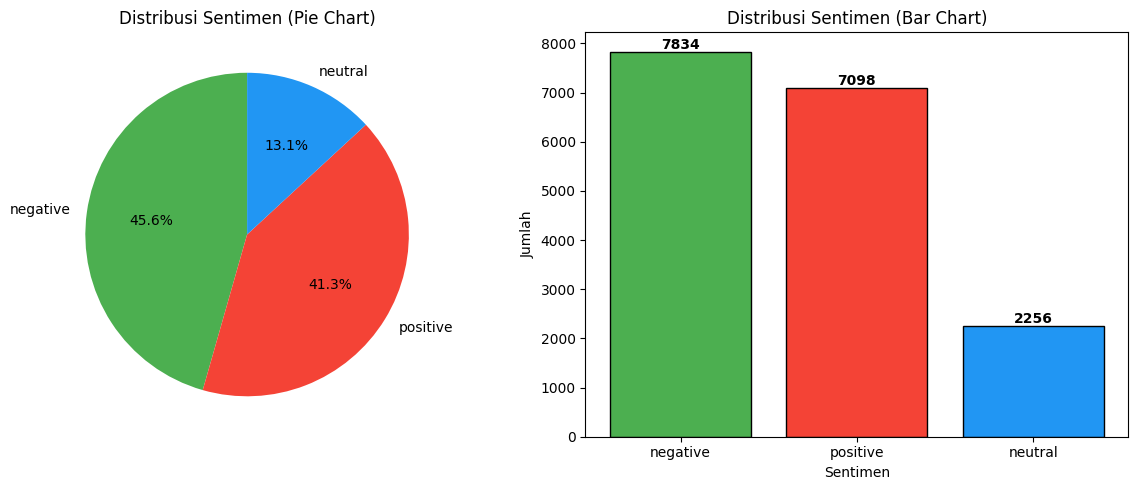

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sentiment_counts = df['sentiment'].value_counts()
colors = ['#4CAF50', '#F44336', '#2196F3']

# Pie chart
axes[0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('Distribusi Sentimen (Pie Chart)')

# Bar chart
axes[1].bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black')
axes[1].set_title('Distribusi Sentimen (Bar Chart)')
axes[1].set_xlabel('Sentimen')
axes[1].set_ylabel('Jumlah')
for i, v in enumerate(sentiment_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/visualizations/sentiment_distribution.png', dpi=100)
plt.show()

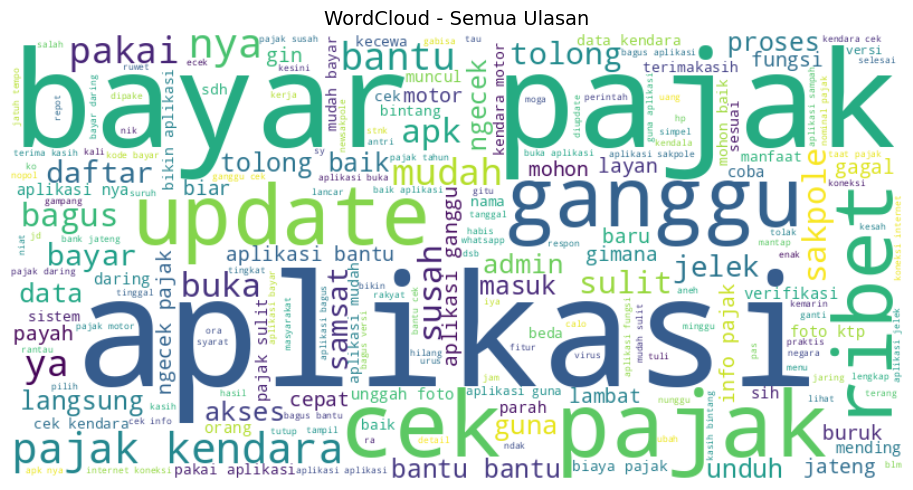

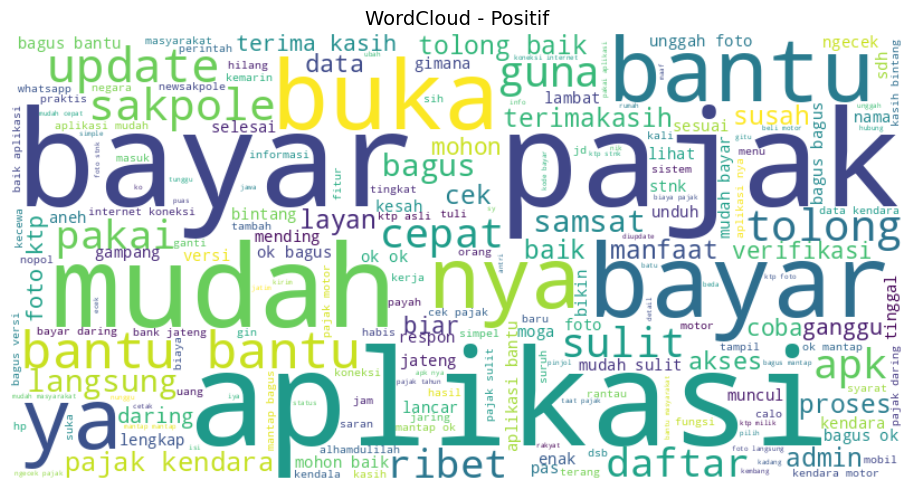

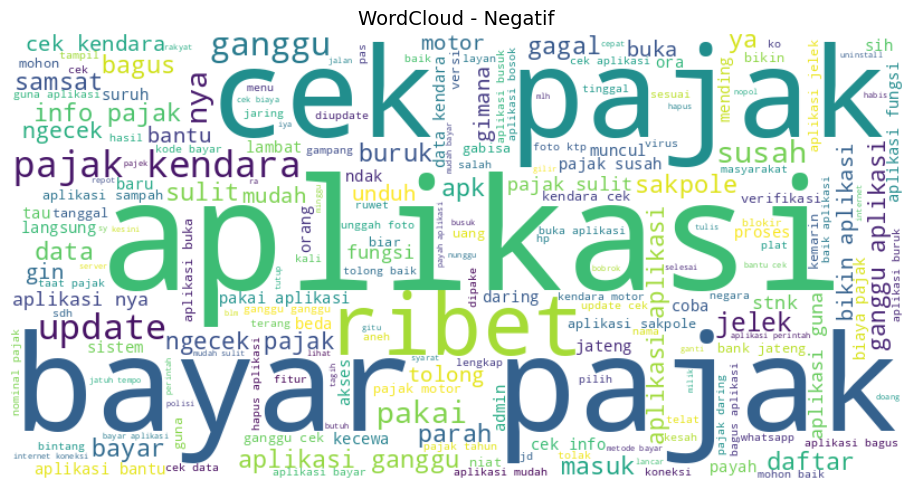

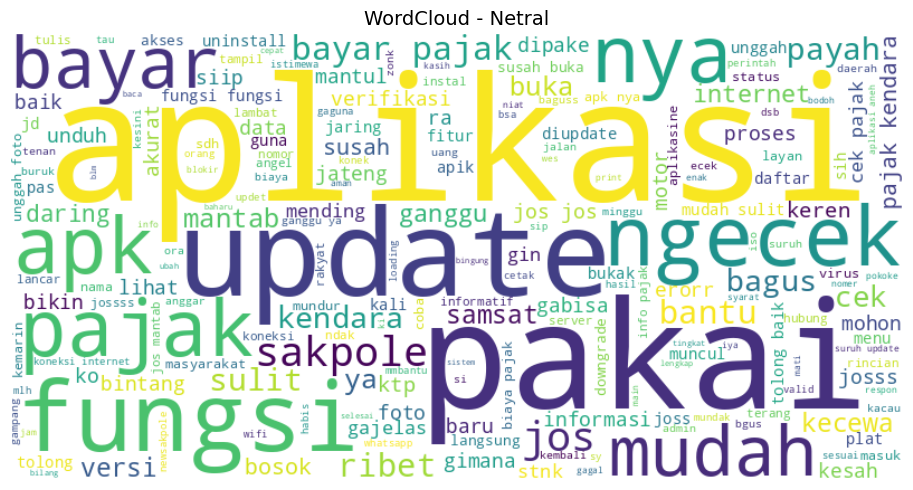

In [18]:
def generate_wordcloud(text_series, title, save_path):
    all_text = ' '.join(text_series.dropna().astype(str))
    if not all_text.strip():
        print(f"Tidak ada teks untuk: {title}")
        return
    wc = WordCloud(width=800, height=400, background_color='white',
                   max_words=200, colormap='viridis').generate(all_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=100)
    plt.show()

generate_wordcloud(df['clean_text'], 'WordCloud - Semua Ulasan',
                   '/content/visualizations/wc_all.png')
generate_wordcloud(df[df['sentiment']=='positive']['clean_text'], 'WordCloud - Positif',
                   '/content/visualizations/wc_positive.png')
generate_wordcloud(df[df['sentiment']=='negative']['clean_text'], 'WordCloud - Negatif',
                   '/content/visualizations/wc_negative.png')
generate_wordcloud(df[df['sentiment']=='neutral']['clean_text'], 'WordCloud - Netral',
                   '/content/visualizations/wc_neutral.png')

In [19]:
os.makedirs('data', exist_ok=True)

# Cleaned
df_cleaned = df.copy()
df_cleaned.to_csv('cleaned_reviews_new_sakpole.csv', index=False, encoding='utf-8-sig')
print("Saved: cleaned_reviews_new_sakpole.csv")

# Labeled
df_labeled = df[['content', 'clean_text', 'sentiment_score', 'sentiment']].copy()
if 'score' in df.columns:
    df_labeled['score'] = df['score']
if 'at' in df.columns:
    df_labeled['at'] = df['at']
df_labeled.to_csv('labeled_reviews_new_sakpole.csv', index=False, encoding='utf-8-sig')
print("Saved: labeled_reviews_new_sakpole.csv")

# Final - kolom lengkap yang dibutuhkan training
keep_cols = ['content', 'clean_text', 'sentiment_score', 'sentiment']
for extra in ['score', 'at', 'userName', 'thumbsUpCount']:
    if extra in df.columns:
        keep_cols.append(extra)
df_final = df[keep_cols].copy()
df_final.to_csv('final_reviews_new_sakpole.csv', index=False, encoding='utf-8-sig')
print("Saved: final_reviews_new_sakpole.csv")

print(f"\nTotal data final: {len(df_final)}")
print(df_final['sentiment'].value_counts())

Saved: cleaned_reviews_new_sakpole.csv
Saved: labeled_reviews_new_sakpole.csv
Saved: final_reviews_new_sakpole.csv

Total data final: 17188
sentiment
negative    7834
positive    7098
neutral     2256
Name: count, dtype: int64
